# 7. Readmission Decision Analysis

Predictive performance alone does not determine how hospitals should allocate limited post-discharge resources. The practical challenge is deciding which patients should receive additional support first when care-management capacity is constrained.

This notebook translates validated 30-day readmission risk scores into a decision-support framework. The analysis examines how readmissions are distributed across predicted risk, how effectively higher-risk patients can be prioritized, and how different levels of care-management capacity affect the proportion of readmissions that can be reached.

The analysis follows the framework:

**Healthcare Utilization → Readmission Risk → Patient Prioritization → Resource Allocation**

## 7.1 From Prediction to Decision

Model evaluation showed that the predicted probabilities are more useful for ranking relative readmission risk than for making binary predictions at the default classification threshold.

For resource allocation, this distinction is important. Hospitals may not need to classify every patient as either high or low risk using a single probability threshold. Instead, patients can be ranked according to predicted risk and prioritized according to the amount of post-discharge support available.

The decision-analysis stage therefore focuses on three questions:

1. **Does observed readmission increase as predicted risk increases?**
2. **How many actual readmissions can be reached by prioritizing the highest-risk patients?**
3. **How should different levels of post-discharge support be allocated when care-management capacity is limited?**

These questions shift the analysis from evaluating predictive performance to determining how the model could support practical resource-allocation decisions.

## 7.2 Decision Dataset Setup

The held-out test-set predictions generated during model evaluation are used for decision analysis.

Each encounter contains its observed 30-day readmission outcome, predicted readmission probability, risk ranking, and the patient and encounter characteristics required for subsequent prioritization and profiling analyses.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

decision_data = pd.read_csv(
    "../data/processed/readmission_risk_predictions.csv"
)

print("Dataset shape:", decision_data.shape)
print("Actual readmissions:", decision_data["actual_readmission"].sum())
print(
    "Readmission rate:",
    f"{decision_data['actual_readmission'].mean():.2%}"
)

Dataset shape: (20093, 38)
Actual readmissions: 2195
Readmission rate: 10.92%


Validate.

In [2]:
decision_data[
    [
        "predicted_probability",
        "risk_rank",
        "risk_percentile"
    ]
].describe().round(3)

,predicted_probability,risk_rank,risk_percentile
count,20093.000,20093.000,20093.000
mean,0.111,10047.000,50.002
std,0.067,5800.494,28.868
min,0.001,1.000,0.005
25%,0.066,5024.000,25.004
50%,0.095,10047.000,50.002
75%,0.135,15070.000,75.001
max,0.705,20093.000,100.000


## 7.3 Risk Concentration Analysis

Before determining how patients should be prioritized for additional support, the analysis first examines whether observed readmissions are concentrated among encounters assigned higher predicted risk.

Patients are divided into ten equally sized groups based on predicted readmission probability, with **Decile 1 representing the highest-risk 10% of encounters**.

A useful risk-ranking model should show higher observed readmission rates and a greater concentration of actual readmissions toward the highest-risk deciles.

In [3]:
decision_data["risk_decile"] = pd.qcut(
    decision_data["predicted_probability"],
    q=10,
    labels=range(10, 0, -1)
).astype(int)

decile_summary = (
    decision_data
    .groupby("risk_decile")
    .agg(
        Encounters=("actual_readmission", "size"),
        Readmissions=("actual_readmission", "sum"),
        Mean_Predicted_Risk=("predicted_probability", "mean"),
        Readmission_Rate=("actual_readmission", "mean")
    )
    .reset_index()
    .sort_values("risk_decile")
)

decile_summary["Share_of_Readmissions"] = (
    decile_summary["Readmissions"]
    / decision_data["actual_readmission"].sum()
)

decile_summary.round(3)

,risk_decile,Encounters,Readmissions,Mean_Predicted_Risk,Readmission_Rate,Share_of_Readmissions
0,1,2010,563,0.262,0.280,0.256
1,2,2009,336,0.168,0.167,0.153
2,3,2009,254,0.136,0.126,0.116
3,4,2009,222,0.117,0.111,0.101
4,5,2009,195,0.103,0.097,0.089
5,6,2010,154,0.089,0.077,0.070
6,7,2009,147,0.077,0.073,0.067
7,8,2009,146,0.066,0.073,0.067
8,9,2009,106,0.055,0.053,0.048
9,10,2010,72,0.035,0.036,0.033


Verify

In [4]:
decile_summary[
    [
        "risk_decile",
        "Mean_Predicted_Risk",
        "Readmission_Rate"
    ]
].round(3)

,risk_decile,Mean_Predicted_Risk,Readmission_Rate
0,1,0.262,0.280
1,2,0.168,0.167
2,3,0.136,0.126
3,4,0.117,0.111
4,5,0.103,0.097
5,6,0.089,0.077
6,7,0.077,0.073
7,8,0.066,0.073
8,9,0.055,0.053
9,10,0.035,0.036


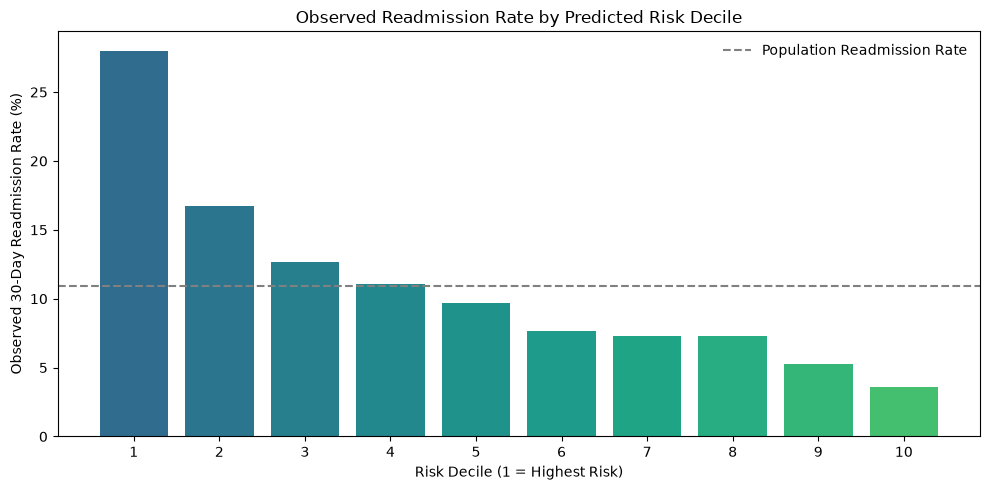

In [5]:
# Viridis blue–teal–green range
colors = plt.cm.viridis(np.linspace(0.35, 0.70, len(decile_summary)))

plt.figure(figsize=(10, 5))

bars = plt.bar(
    decile_summary["risk_decile"].astype(str),
    decile_summary["Readmission_Rate"] * 100,
    color=colors
)

plt.axhline(
    decision_data["actual_readmission"].mean() * 100,
    linestyle="--",
    linewidth=1.5,
    color="gray",
    label="Population Readmission Rate"
)

plt.xlabel("Risk Decile (1 = Highest Risk)")
plt.ylabel("Observed 30-Day Readmission Rate (%)")
plt.title("Observed Readmission Rate by Predicted Risk Decile")

plt.legend(frameon=False)

plt.tight_layout()
plt.show()

### Risk Concentration Interpretation

Observed 30-day readmission rates increase substantially toward the higher end of the model's risk ranking.

The **highest-risk decile recorded a 28.0% readmission rate**, compared with **3.6% in the lowest-risk decile**. The highest-risk group therefore experienced readmission at approximately **7.8 times the rate of the lowest-risk group**.

The highest-risk decile also had an observed readmission rate well above the **10.9% population rate**, while the lower-risk deciles generally fell below this baseline. Although the relationship is not perfectly monotonic across every adjacent decile, the broader pattern shows a clear concentration of readmission risk toward the top of the ranking.

This provides evidence that the predicted probabilities can meaningfully differentiate higher- and lower-risk encounters and supports their use for patient prioritization. The next analysis therefore examines how many actual readmissions could be reached when post-discharge resources are concentrated on progressively larger portions of the highest-risk population.

## 7.4 Patient Prioritization and Readmission Capture

Hospitals may have sufficient post-discharge resources to support only a limited proportion of patients. Risk-based prioritization can therefore be evaluated by measuring how many actual readmissions are concentrated within progressively larger portions of the highest-risk population.

Patients are ranked from highest to lowest predicted readmission risk. The analysis then evaluates the proportion of actual readmissions captured when resources are allocated to the top 5%, 10%, 20%, 30%, 40%, and 50% of encounters.

This provides a direct measure of how effectively predicted risk could support patient prioritization under different levels of resource availability.

In [6]:
ranked_data = decision_data.sort_values(
    "predicted_probability",
    ascending=False
).reset_index(drop=True)

target_shares = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50]

total_encounters = len(ranked_data)
total_readmissions = ranked_data["actual_readmission"].sum()

capture_results = []

for share in target_shares:
    n_targeted = int(np.ceil(total_encounters * share))
    targeted = ranked_data.iloc[:n_targeted]

    readmissions_captured = targeted["actual_readmission"].sum()

    capture_results.append({
        "Population Targeted (%)": share * 100,
        "Patients Targeted": n_targeted,
        "Readmissions Captured": int(readmissions_captured),
        "Readmissions Captured (%)":
            readmissions_captured / total_readmissions * 100,
        "Targeted Group Readmission Rate (%)":
            targeted["actual_readmission"].mean() * 100
    })

capture_df = pd.DataFrame(capture_results)

capture_df.round(1)

,Population Targeted (%),Patients Targeted,Readmissions Captured,Readmissions Captured (%),Targeted Group Readmission Rate (%)
0,5.0,1005,334,15.2,33.2
1,10.0,2010,563,25.6,28.0
2,20.0,4019,899,41.0,22.4
3,30.0,6028,1153,52.5,19.1
4,40.0,8038,1375,62.6,17.1
5,50.0,10047,1570,71.5,15.6


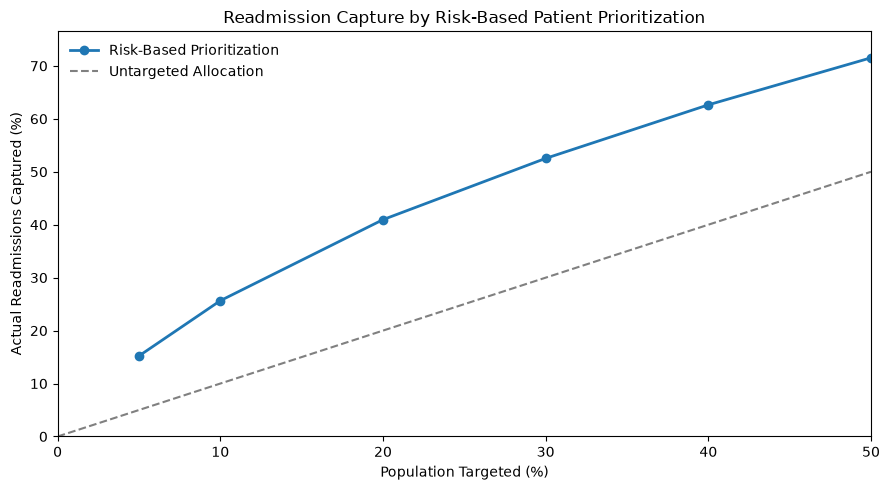

In [7]:
plt.figure(figsize=(9, 5))

plt.plot(
    capture_df["Population Targeted (%)"],
    capture_df["Readmissions Captured (%)"],
    marker="o",
    linewidth=2,
    label="Risk-Based Prioritization"
)

plt.plot(
    [0, 50],
    [0, 50],
    linestyle="--",
    color="gray",
    label="Untargeted Allocation"
)

plt.xlabel("Population Targeted (%)")
plt.ylabel("Actual Readmissions Captured (%)")
plt.title("Readmission Capture by Risk-Based Patient Prioritization")

plt.xlim(0, 50)
plt.ylim(0, max(55, capture_df["Readmissions Captured (%)"].max() + 5))

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

### Patient Prioritization Interpretation

Risk-based prioritization concentrates a disproportionate share of observed readmissions within the highest-risk patients.

Targeting the **highest-risk 5% of encounters** would prioritize 1,005 patients and include **15.2% of all observed readmissions**. Expanding capacity to the highest-risk **10%** would reach **25.6% of readmissions**, while targeting the highest-risk **20%** would reach **41.0%**.

At larger capacity levels, the highest-risk **30% of encounters contain 52.5% of observed readmissions**, and the highest-risk **50% contain 71.5%**.

The readmission rate within the targeted population declines as capacity expands, from **33.2% among the highest-risk 5%** to **15.6% among the highest-risk 50%**. This reflects diminishing risk concentration as progressively lower-ranked patients are included.

These findings demonstrate the operational value of risk ranking: limited post-discharge resources can be concentrated on a smaller patient population while reaching a substantially larger share of patients who subsequently experience 30-day readmission. The appropriate targeting level therefore depends on available care-management capacity rather than a single universal classification threshold.

## 7.5 Lift Analysis

Readmission capture measures the proportion of observed readmissions contained within a targeted patient group, but it does not directly quantify the advantage of risk-based prioritization relative to untargeted resource allocation.

Lift compares the share of readmissions captured with the share of the population targeted. A lift greater than 1 indicates that risk-based prioritization identifies readmissions more efficiently than allocating the same level of resources without using the model's risk ranking.

Higher lift therefore represents greater concentration of readmission risk within the prioritized population.

In [8]:
lift_df = capture_df[
    [
        "Population Targeted (%)",
        "Patients Targeted",
        "Readmissions Captured (%)"
    ]
].copy()

lift_df["Lift"] = (
    lift_df["Readmissions Captured (%)"]
    / lift_df["Population Targeted (%)"]
)

lift_df.round(2)

,Population Targeted (%),Patients Targeted,Readmissions Captured (%),Lift
0,5.0,1005,15.22,3.04
1,10.0,2010,25.65,2.56
2,20.0,4019,40.96,2.05
3,30.0,6028,52.53,1.75
4,40.0,8038,62.64,1.57
5,50.0,10047,71.53,1.43


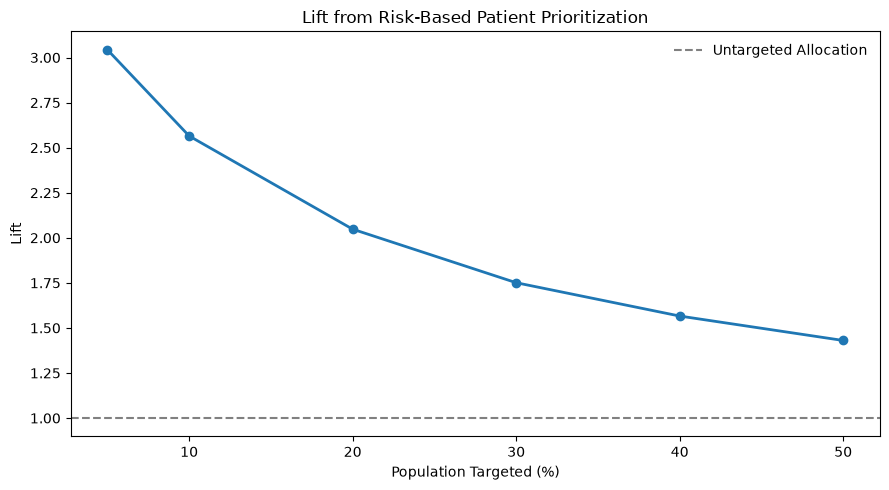

In [9]:
plt.figure(figsize=(9, 5))

plt.plot(
    lift_df["Population Targeted (%)"],
    lift_df["Lift"],
    marker="o",
    linewidth=2
)

plt.axhline(
    1,
    linestyle="--",
    color="gray",
    label="Untargeted Allocation"
)

plt.xlabel("Population Targeted (%)")
plt.ylabel("Lift")
plt.title("Lift from Risk-Based Patient Prioritization")

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

### Lift Analysis Interpretation

Risk-based prioritization provides the greatest advantage when post-discharge resources are most constrained.

Targeting only the **highest-risk 5% of encounters** produces a lift of **3.04**, meaning that this group contains approximately three times the share of observed readmissions that would be expected under untargeted allocation. At **10% capacity**, lift remains substantial at **2.56**, with 25.6% of observed readmissions concentrated within 10% of encounters.

As the targeted population expands, lift gradually declines: **2.05 at 20%**, **1.75 at 30%**, and **1.43 at 50%**. This reflects diminishing risk concentration as progressively lower-ranked patients are added to the intervention population.

The pattern suggests that the model provides its greatest prioritization value when resources are scarce. Additional capacity continues to reach more readmissions, but each expansion includes patients with progressively lower concentrations of observed readmission risk.

## 7.6 Care-Management Capacity Analysis

Percentage-based targeting demonstrates the value of risk ranking, but operational resource planning is often expressed as the number of patients a care-management team can support.

To translate the risk ranking into practical workload scenarios, the analysis evaluates several hypothetical capacity levels. At each capacity, patients are selected from the top of the predicted-risk ranking and the number and proportion of observed readmissions within the prioritized group are calculated.

These scenarios do not prescribe an optimal staffing level. Instead, they demonstrate how different levels of available post-discharge capacity translate into patient reach and readmission coverage.

In [10]:
capacity_levels = [100, 250, 500, 1000, 2000, 4000]

capacity_results = []

for capacity in capacity_levels:
    targeted = ranked_data.iloc[:capacity]

    readmissions = targeted["actual_readmission"].sum()

    capacity_results.append({
        "Patient Capacity": capacity,
        "Population Reached (%)":
            capacity / total_encounters * 100,
        "Readmissions Captured": int(readmissions),
        "Readmissions Captured (%)":
            readmissions / total_readmissions * 100,
        "Targeted Group Readmission Rate (%)":
            targeted["actual_readmission"].mean() * 100
    })

capacity_df = pd.DataFrame(capacity_results)

capacity_df.round(1)

,Patient Capacity,Population Reached (%),Readmissions Captured,Readmissions Captured (%),Targeted Group Readmission Rate (%)
0,100,0.5,56,2.6,56.0
1,250,1.2,110,5.0,44.0
2,500,2.5,199,9.1,39.8
3,1000,5.0,334,15.2,33.4
4,2000,10.0,562,25.6,28.1
5,4000,19.9,895,40.8,22.4


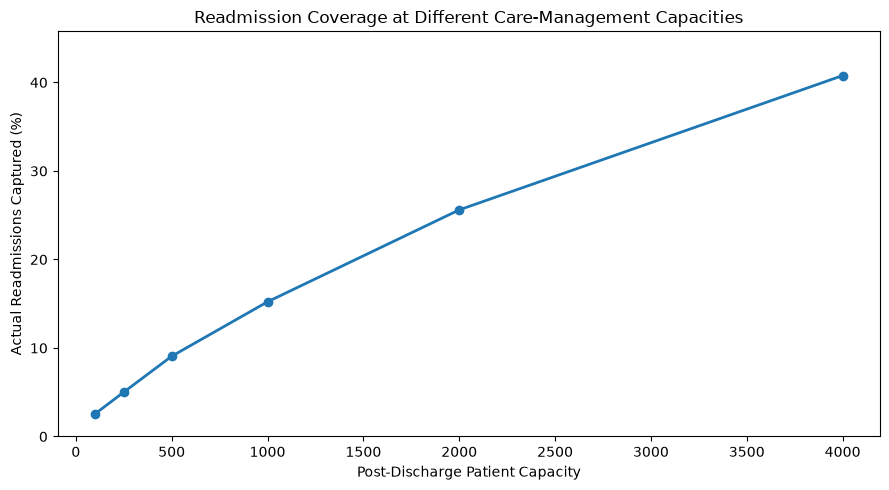

In [11]:
plt.figure(figsize=(9, 5))

plt.plot(
    capacity_df["Patient Capacity"],
    capacity_df["Readmissions Captured (%)"],
    marker="o",
    linewidth=2
)

plt.xlabel("Post-Discharge Patient Capacity")
plt.ylabel("Actual Readmissions Captured (%)")
plt.title("Readmission Coverage at Different Care-Management Capacities")

plt.ylim(
    0,
    capacity_df["Readmissions Captured (%)"].max() + 5
)

plt.tight_layout()
plt.show()

### Care-Management Capacity Interpretation

The capacity analysis demonstrates how the proportion of readmissions reached changes as more patients are included in post-discharge support.

With capacity for only **100 patients**, representing approximately **0.5% of encounters**, the highest-risk group contains **56 observed readmissions**, or **2.6% of all readmissions**, and has a readmission rate of **56.0%**.

Expanding capacity to **500 patients** reaches **199 observed readmissions (9.1%)**, while capacity for **1,000 patients** reaches **334 readmissions (15.2%)**. At **2,000 patients**, approximately 10% of the population, the prioritized group contains **25.6% of observed readmissions**.

A capacity of **4,000 patients**, representing approximately 20% of encounters, extends coverage to **40.8% of observed readmissions**.

As capacity increases, total readmission coverage improves while the readmission rate within the targeted group declines. This reflects the operational trade-off between **concentrating intensive resources on a smaller, higher-risk population and extending support to a broader group that captures more total readmissions**.

The results provide a flexible resource-allocation framework rather than a single recommended capacity level. Hospitals can align the depth of the risk ranking with available staffing and post-discharge resources.

## 7.7 High-Risk Patient Profile

Understanding who appears at the top of the risk ranking is important for translating predicted risk into practical care-management strategies.

For profiling purposes, the **highest-risk 10% of encounters** are compared with the remaining 90% of the population. This cutoff is used to characterize the patients most strongly prioritized by the model and does not represent a prescribed intervention threshold.

The analysis focuses on healthcare utilization and clinical-complexity characteristics that may help care-management teams understand the needs of the prioritized population.

### 7.7.1 Utilization and Clinical Complexity

Prior healthcare utilization and clinical complexity were important themes in both exploratory analysis and model interpretation.

The following analysis compares average prior inpatient, emergency, and outpatient utilization together with diagnosis burden, length of stay, medication use, and laboratory activity between the highest-risk 10% of encounters and the remaining population.

In [12]:
high_risk_cutoff = int(np.ceil(len(ranked_data) * 0.10))

ranked_data["Risk Group"] = "Remaining 90%"
ranked_data.loc[
    :high_risk_cutoff - 1,
    "Risk Group"
] = "Highest-Risk 10%"

profile_features = [
    "number_inpatient",
    "number_emergency",
    "number_outpatient",
    "number_diagnoses",
    "time_in_hospital",
    "num_medications",
    "num_lab_procedures"
]

high_risk_profile = (
    ranked_data
    .groupby("Risk Group")[profile_features]
    .mean()
    .T
)

high_risk_profile["Difference"] = (
    high_risk_profile["Highest-Risk 10%"]
    - high_risk_profile["Remaining 90%"]
)

high_risk_profile.round(2)

Risk Group,Highest-Risk 10%,Remaining 90%,Difference
number_inpatient,2.76,0.36,2.39
number_emergency,0.68,0.13,0.55
number_outpatient,0.58,0.33,0.25
number_diagnoses,7.72,7.37,0.36
time_in_hospital,5.29,4.33,0.96
num_medications,18.59,15.82,2.77
num_lab_procedures,44.80,42.77,2.03


### High-Risk Patient Profile Interpretation

The highest-risk patients are distinguished most clearly by substantially greater prior healthcare utilization.

Patients in the **highest-risk 10% averaged 2.76 prior inpatient visits**, compared with **0.36** among the remaining population. Prior emergency utilization was also considerably higher (**0.68 vs. 0.13 visits**), while outpatient utilization showed a smaller difference (**0.58 vs. 0.33**).

The highest-risk group also showed greater clinical complexity and resource use during the current encounter. They had longer average hospital stays (**5.29 vs. 4.33 days**), received more medications (**18.59 vs. 15.82**), and underwent slightly more laboratory procedures (**44.80 vs. 42.77**). Diagnosis burden was only modestly higher (**7.72 vs. 7.37 diagnoses**).

These findings reinforce the earlier EDA and model-interpretation results: **recent patterns of hospital utilization, particularly prior inpatient and emergency use, are central characteristics of the patients ranked at highest readmission risk**. Clinical complexity contributes additional information but differentiates the groups less strongly.

From a resource-allocation perspective, the highest-risk population therefore represents not only patients with elevated predicted readmission risk, but also a group with substantially greater prior interaction with acute-care services.

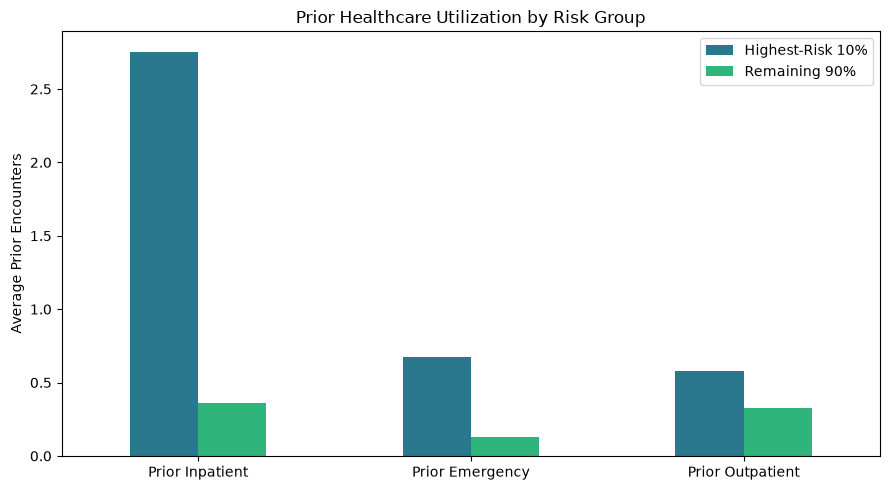

In [13]:
utilization_features = [
    "number_inpatient",
    "number_emergency",
    "number_outpatient"
]

utilization_plot = (
    high_risk_profile
    .loc[utilization_features, ["Highest-Risk 10%", "Remaining 90%"]]
    .rename(index={
        "number_inpatient": "Prior Inpatient",
        "number_emergency": "Prior Emergency",
        "number_outpatient": "Prior Outpatient"
    })
)

ax = utilization_plot.plot(
    kind="bar",
    figsize=(9, 5),
    color=[
        plt.cm.viridis(0.40),
        plt.cm.viridis(0.65)
    ]
)

plt.xlabel("")
plt.ylabel("Average Prior Encounters")
plt.title("Prior Healthcare Utilization by Risk Group")

plt.xticks(rotation=0)
plt.legend(title="")
plt.tight_layout()
plt.show()

### Prior Utilization Interpretation

Prior healthcare utilization differs substantially between the highest-risk patients and the rest of the population. The most pronounced difference occurs in **prior inpatient utilization**, where the highest-risk 10% averaged **2.76 prior inpatient encounters compared with 0.36** among the remaining 90%. Prior emergency utilization was also considerably higher (**0.68 vs. 0.13**), while the difference in outpatient utilization was smaller (**0.58 vs. 0.33**).

This pattern reinforces prior utilization as a key characteristic of patients receiving the highest risk rankings, particularly repeated interaction with inpatient and emergency car

### 7.7.2 Discharge Characteristics

Discharge disposition was one of the most influential features in the readmission-risk model. To provide additional context for the high-risk patient profile, discharge patterns are compared between the highest-risk 10% of encounters and the remaining population.

The analysis focuses on whether particular discharge dispositions are disproportionately represented among patients receiving the highest risk rankings.

In [16]:
discharge_profile = pd.crosstab(
    ranked_data["discharge_disposition_id"],
    ranked_data["Risk Group"],
    normalize="columns"
) * 100

discharge_profile["Difference"] = (
    discharge_profile["Highest-Risk 10%"]
    - discharge_profile["Remaining 90%"]
)

discharge_profile = (
    discharge_profile
    .sort_values("Difference", ascending=False)
)

discharge_profile.head(5).round(1)

Risk Group,Highest-Risk 10%,Remaining 90%,Difference
discharge_disposition_id,,,
22,15.3,0.6,14.8
3,18.8,13.0,5.8
5,3.8,0.8,2.9
6,15.1,12.8,2.3
28,1.4,0.0,1.4


### Discharge Profile Interpretation

Discharge patterns differed between the highest-risk patients and the remaining population. The largest difference occurred for discharge disposition ID 22, which represented **15.3% of the highest-risk group compared with 0.6% of the remaining population**.

Several other discharge categories were also more common among the highest-risk patients, although the differences were smaller.

These results support discharge disposition as an additional characteristic associated with the model's risk ranking. However, prior healthcare utilization remains the clearest operational distinction identified in the high-risk patient profile.

## 7.8 Risk-Based Support Framework

The preceding analyses show that readmission risk is concentrated within a relatively small proportion of patients and that the value of risk-based prioritization is greatest when care-management resources are limited.

Rather than applying a single probability threshold to classify patients as high or low risk, post-discharge support can be organized according to each patient's position in the risk ranking. This allows the intensity of support to increase for patients with greater predicted risk while preserving a standard pathway for the broader population.

The following framework translates the observed risk concentration and readmission-capture results into potential levels of post-discharge support.

In [17]:
support_framework = pd.DataFrame({
    "Priority Level": [
        "Highest Priority",
        "Elevated Priority",
        "Moderate Priority",
        "Standard Pathway"
    ],
    "Risk Ranking": [
        "Top 5%",
        "5–20%",
        "20–30%",
        "Remaining 70%"
    ],
    "Potential Support": [
        "Intensive transitional-care review",
        "Structured post-discharge follow-up",
        "Routine follow-up with monitoring",
        "Standard post-discharge care"
    ]
})

support_framework

,Priority Level,Risk Ranking,Potential Support
0,Highest Priority,Top 5%,Intensive transitional-care review
1,Elevated Priority,5–20%,Structured post-discharge follow-up
2,Moderate Priority,20–30%,Routine follow-up with monitoring
3,Standard Pathway,Remaining 70%,Standard post-discharge care


### Resource-Allocation Interpretation

The proposed framework translates the model's risk ranking into progressively different levels of post-discharge support.

The **highest-risk 5%** form the Highest Priority group and represent the most concentrated segment of readmission risk. Although this group contains only 5% of encounters, it accounts for **15.2% of observed readmissions** and produces a lift of **3.04** relative to untargeted allocation.

The next **15% of patients (5–20%)** form the Elevated Priority group. When the Highest and Elevated Priority groups are combined, the highest-risk **20% of encounters capture 41.0% of observed readmissions**, with a cumulative lift of **2.05**.

The next **10% (20–30%)** form the Moderate Priority group. Extending support through this group means that the highest-risk **30% of encounters collectively capture 52.5% of observed readmissions**.

The remaining **70%** follow the Standard Pathway because the concentration of observed readmissions becomes progressively lower further down the risk ranking.

This framework does not prescribe clinical treatment or fixed staffing levels. Instead, it demonstrates how predicted risk could be used to prioritize **additional post-discharge support** according to available care-management capacity, with clinical judgment and individual patient needs continuing to guide final care decisions.

## 7.9 Missed Readmission Analysis

Risk-based prioritization concentrates post-discharge resources on patients with the highest predicted risk, but not all subsequent readmissions occur within these groups.

To examine this limitation, the highest-risk 20% of encounters is used as a reference prioritization scenario. This level was selected because it captures a substantial share of observed readmissions while limiting additional support to one-fifth of the population.

The analysis compares readmissions captured within the highest-risk 20% with readmissions occurring among the remaining 80%. This helps quantify the proportion of readmissions that would remain outside the prioritized population.

In [18]:
top_20_cutoff = int(np.ceil(len(ranked_data) * 0.20))

ranked_data["Top 20% Priority"] = False
ranked_data.loc[
    :top_20_cutoff - 1,
    "Top 20% Priority"
] = True

readmitted_patients = ranked_data[
    ranked_data["actual_readmission"] == 1
]

missed_summary = pd.DataFrame({
    "Readmission Group": [
        "Captured in Top 20%",
        "Outside Top 20%"
    ],
    "Readmissions": [
        readmitted_patients["Top 20% Priority"].sum(),
        (~readmitted_patients["Top 20% Priority"]).sum()
    ]
})

missed_summary["Share of Readmissions (%)"] = (
    missed_summary["Readmissions"]
    / missed_summary["Readmissions"].sum()
    * 100
)

missed_summary.round(1)

,Readmission Group,Readmissions,Share of Readmissions (%)
0,Captured in Top 20%,899,41.0
1,Outside Top 20%,1296,59.0


### Missed Readmission Interpretation

Prioritizing the highest-risk 20% of encounters would reach **899 of the 2,195 observed readmissions**, representing **41.0% of all readmissions**.

However, **1,296 readmissions (59.0%)** occurred outside this prioritized group. This highlights an important limitation of risk-based targeting: although the model concentrates readmission risk more efficiently than untargeted allocation, a substantial proportion of readmissions cannot be identified within a resource-constrained priority group.

The result reinforces that predicted risk should be used to prioritize **additional post-discharge support rather than determine access to care**. Patients outside the highest-risk group should continue to receive standard post-discharge care, while clinical judgment and other relevant information may identify additional patients who require greater support.

The choice of prioritization capacity therefore involves a trade-off. Restricting resources to a smaller high-risk population improves targeting efficiency, while expanding capacity increases the proportion of readmissions reached.

## 7.10 Economic Impact Scenarios

Risk-based prioritization identifies patients who could receive additional post-discharge support, but the dataset does not contain information on intervention effectiveness, intervention costs, or the financial cost of a readmission.

Economic impact is therefore evaluated using hypothetical scenarios rather than estimated savings. Using the highest-risk 20% as the reference population, the analysis examines how many readmissions could potentially be avoided under different assumed levels of intervention effectiveness.

These scenarios are illustrative and should not be interpreted as causal estimates of intervention impact.

In [19]:
targeted_patients = top_20_cutoff
targeted_readmissions = 899

effectiveness_levels = [0.05, 0.10, 0.20]

impact_scenarios = pd.DataFrame({
    "Assumed Intervention Effectiveness (%)": [
        e * 100 for e in effectiveness_levels
    ],
    "Patients Targeted": targeted_patients,
    "Observed Readmissions in Targeted Group": targeted_readmissions,
    "Potential Readmissions Avoided": [
        targeted_readmissions * e
        for e in effectiveness_levels
    ]
})

impact_scenarios["Potential Readmissions Avoided"] = (
    impact_scenarios["Potential Readmissions Avoided"]
    .round(0)
    .astype(int)
)

impact_scenarios

,Assumed Intervention Effectiveness (%),Patients Targeted,Observed Readmissions in Targeted Group,Potential Readmissions Avoided
0,5.0,4019,899,45
1,10.0,4019,899,90
2,20.0,4019,899,180


### Economic Impact Scenario Interpretation

The scenario analysis illustrates how risk-based prioritization could translate into potential reductions in readmissions if post-discharge interventions are effective.

Under the highest-risk 20% targeting strategy, **4,019 patients** would be prioritized, including **899 patients who experienced a 30-day readmission**.

If additional post-discharge support prevented **5% of readmissions within this targeted group**, approximately **45 readmissions** could potentially be avoided. At assumed effectiveness levels of **10% and 20%**, the corresponding estimates increase to approximately **90 and 180 potentially avoided readmissions**, respectively.

These estimates are scenario-based rather than predicted intervention outcomes. The dataset does not measure the effectiveness or cost of post-discharge interventions, and the analysis therefore does not estimate actual financial savings.

In practice, hospitals could extend this framework using organization-specific estimates of intervention cost, readmission cost, and expected intervention effectiveness to evaluate the financial implications of different resource-allocation strategies.

## 7.11 Decision Recommendations

The analysis supports a resource-allocation strategy in which predicted readmission risk is used to determine the order in which patients are considered for additional post-discharge support.

### 1. Prioritize patients by relative readmission risk

The model should primarily be used to **rank patients rather than classify them using the default 0.50 probability threshold**. The highest-risk groups contain a disproportionate share of observed readmissions, making risk ranking more useful for allocating constrained resources.

### 2. Match the size of the priority population to available capacity

Hospitals can adjust the proportion of patients receiving additional support according to available care-management capacity.

- The highest-risk **5%** captures **15.2% of observed readmissions** with a lift of **3.04**.
- Expanding through the highest-risk **20%** captures **41.0% of observed readmissions** with a lift of **2.05**.
- Extending through the highest-risk **30%** captures **52.5% of observed readmissions**.

This allows resource allocation to respond to staffing capacity rather than depend on a single fixed risk threshold.

### 3. Use prior utilization to provide additional operational context

Patients receiving the highest risk rankings had substantially greater prior inpatient and emergency utilization. Prior inpatient use was particularly distinctive, averaging **2.76 previous encounters among the highest-risk 10% compared with 0.36 among the remaining population**.

Care-management teams can therefore consider predicted risk together with recent utilization history when reviewing patients for additional post-discharge support.

### 4. Use different levels of additional support

The risk ranking can support a tiered approach in which the highest-risk patients are considered first for more intensive transitional-care review, followed by structured or routine follow-up for progressively lower priority groups.

These support levels represent potential operational pathways rather than clinically validated interventions.

### 5. Maintain standard care beyond the priority population

Risk-based targeting should not be used to exclude lower-ranked patients from appropriate care. Under the highest-risk 20% scenario, **59.0% of observed readmissions occurred outside the prioritized population**.

The model should therefore supplement clinical judgment and existing discharge processes rather than replace them.

### 6. Validate impact before operational deployment

The intervention scenarios indicate that if additional support reduced readmissions within the highest-risk 20% by **5% to 20%**, approximately **45 to 180 readmissions** could potentially be avoided.

These figures are hypothetical. Prospective evaluation would be required to determine actual intervention effectiveness, resource requirements, costs, and patient outcomes before using the framework for operational decision-making.

## 7.12 Limitations and Responsible Use

The decision framework should be interpreted within several important limitations.

**Historical data.** The dataset represents hospital encounters from 1999–2008. Clinical practice, diabetes management, discharge processes, and healthcare delivery have changed substantially since this period. The findings therefore require validation using more recent hospital data before operational deployment.

**Moderate predictive performance.** The model demonstrated useful risk-ranking ability but substantial overlap remained between patients who were and were not readmitted. Risk scores should therefore support prioritization rather than be treated as definitive predictions of individual patient outcomes.

**Incomplete readmission coverage.** Resource-constrained targeting inevitably leaves some readmissions outside the prioritized population. For example, the highest-risk 20% captured 41.0% of observed readmissions, while 59.0% occurred among the remaining patients.

**Predictive rather than causal analysis.** Characteristics associated with higher predicted risk, including prior healthcare utilization, should not be interpreted as causes of readmission. Similarly, the proposed post-discharge support pathways have not been evaluated for causal effectiveness using this dataset.

**Scenario-based intervention impact.** Estimates of potentially avoided readmissions are hypothetical and depend on assumed intervention effectiveness. Actual operational and financial impact would require hospital-specific information on intervention effectiveness, staffing requirements, intervention costs, and readmission costs.

**Responsible clinical use.** Risk scores should be used to prioritize additional support rather than restrict access to care. Clinical judgment, individual patient circumstances, and existing discharge protocols should remain central to final care decisions.

Before implementation, the model should undergo prospective validation, ongoing performance monitoring, and periodic assessment across patient subgroups to identify potential changes in performance or unintended disparities.

## 7.13 Business Question Summary

The analysis can now be translated back to the three business questions that guided the project.

### Business Question 1
**How can hospitals use 30-day readmission risk and healthcare utilization patterns to optimize the allocation of limited post-discharge resources for patients with diabetes?**

Hospitals can use predicted readmission probabilities as a **risk-ranking tool** and allocate additional post-discharge resources from the highest-risk patients downward according to available care-management capacity.

The analysis showed that readmissions are concentrated toward the top of the risk ranking. The highest-risk **5% of encounters contained 15.2% of observed readmissions**, the highest-risk **20% contained 41.0%**, and the highest-risk **30% contained 52.5%**.

This allows hospitals to align the size of the priority population with available resources rather than rely on a single classification threshold.

---

### Business Question 2
**Which patient characteristics and healthcare utilization patterns are associated with higher 30-day readmission risk?**

Prior healthcare utilization emerged as the clearest characteristic associated with elevated readmission risk.

Patients in the highest-risk 10% averaged **2.76 prior inpatient encounters compared with 0.36 among the remaining population**, while prior emergency utilization was also substantially higher. Higher-risk patients also showed somewhat greater length of stay, medication use, laboratory utilization, and other measures of clinical complexity.

Model interpretation reinforced these findings, with **prior inpatient utilization emerging as the strongest predictive feature**. Discharge disposition also contributed meaningfully to the model's risk ranking.

These results suggest that previous interaction with the healthcare system provides important context when identifying patients who may require additional post-discharge attention.

---

### Business Question 3
**How should patients be prioritized across different levels of post-discharge support when care-management capacity is limited?**

Patients can be ranked by predicted readmission risk and assigned progressively different levels of additional support.

The proposed framework prioritizes the **highest-risk 5%** for the most intensive review, the next **15% (5–20%)** for structured post-discharge follow-up, the next **10% (20–30%)** for routine follow-up with additional monitoring, and the remaining population for the standard post-discharge pathway.

The appropriate capacity level depends on available resources. For example, supporting approximately **4,019 highest-risk encounters (20% of the test population)** would reach **899 observed readmissions, or 41.0% of all readmissions**, with a lift of approximately **2.05** compared with untargeted allocation.

Because **59.0% of readmissions still occurred outside this priority group**, risk ranking should determine access to **additional support**, not access to appropriate standard care.

---

### Final Decision Insight

The central finding of this analysis is that 30-day readmission prediction is most valuable when it is used as a **resource-prioritization tool rather than as a standalone binary classification system**.

The Gradient Boosting model demonstrated moderate but consistent ability to rank encounters by relative readmission risk. This ranking translated into meaningful operational separation: the highest-risk decile had an observed readmission rate of **28.0%**, compared with **3.6% in the lowest-risk decile** and **10.9% across the test population**. Although the model cannot determine with certainty which individual patients will be readmitted, it can identify segments of the patient population in which readmissions are substantially more concentrated.

This concentration creates an opportunity for more targeted use of limited post-discharge resources. The highest-risk **5% of encounters contained 15.2% of observed readmissions**, producing a lift of **3.04** relative to untargeted allocation. Expanding support to the highest-risk **20% captured 41.0% of readmissions**, while extending through the highest-risk **30% captured 52.5%**. The appropriate prioritization level is therefore not a universal probability threshold; it is a **capacity decision** that depends on how many patients the hospital can realistically support.

The analysis also provides important context for understanding who appears toward the top of the risk ranking. Prior healthcare utilization was the clearest distinguishing characteristic. Patients in the highest-risk 10% averaged **2.76 prior inpatient encounters compared with 0.36 among the remaining population**, and prior emergency utilization was also substantially higher. Prior inpatient utilization was likewise the strongest feature in model interpretation. Measures of clinical complexity and discharge disposition provided additional information, but the utilization history of the patient emerged as the most consistent operational signal across exploratory analysis, predictive modeling, and high-risk patient profiling.

These findings support a tiered resource-allocation approach. Patients at the highest end of the ranking could be considered first for intensive transitional-care review, followed by structured follow-up and additional monitoring as care-management capacity expands. This creates a flexible framework in which hospitals can adjust the size of the intervention population without rebuilding the predictive model each time staffing or resource availability changes.

Importantly, prioritization involves a trade-off between **targeting efficiency and readmission coverage**. Concentrating resources on a very small high-risk population produces the greatest lift and the highest concentration of readmissions, but leaves more readmissions outside the intervention group. Expanding capacity reaches a larger share of readmissions but progressively includes patients with lower observed risk. For example, prioritizing the highest-risk **20% of encounters would reach 899 of 2,195 observed readmissions**, but **1,296 readmissions (59.0%) would still occur outside the prioritized population**.

For this reason, predicted risk should determine access to **additional support rather than access to appropriate care**. Patients outside the prioritized population should continue to receive standard post-discharge care, while clinical judgment, individual patient circumstances, and existing discharge processes should remain available to identify patients whose needs may not be fully represented by the model.

The intervention scenarios further illustrate the potential operational value of this framework without assuming that prioritization itself prevents readmissions. Among the **4,019 encounters in the highest-risk 20%**, 899 observed readmissions were reached. If an effective post-discharge intervention prevented **5%, 10%, or 20%** of readmissions within this targeted population, approximately **45, 90, or 180 readmissions**, respectively, could potentially be avoided. These are hypothetical scenarios rather than estimates of realized impact; prospective evaluation would be required to establish actual intervention effectiveness and financial benefit.

Taken together, the project supports the following decision pathway:

**Healthcare Utilization → Readmission Risk → Patient Prioritization → Capacity-Based Resource Allocation → Additional Post-Discharge Support → Potential Operational Impact**

The model therefore serves as a **decision-support layer within the discharge workflow**, not as the final decision-maker. Its value lies in helping hospitals determine where limited additional resources may have the greatest opportunity to reach patients at elevated risk, while allowing the depth of intervention to respond to available capacity.

Before operational use, the framework would require validation using contemporary hospital data, prospective assessment of intervention outcomes, continued subgroup performance monitoring, and integration with clinical workflows. With those safeguards, risk-based prioritization could provide a structured and adaptable approach for directing limited post-discharge resources toward patients with the greatest identified need.